### ML analysis from data collected from model_processing_v3 notebook

In [45]:
#import statements
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import nilearn.image
import nilearn.plotting
import copy
from torch.utils.data import random_split
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from pathlib import Path
import ants
import pydicom
import nibabel as nib
import os
from glob import glob
from tqdm import tqdm
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import balanced_accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from torchinfo import summary
import nilearn

In [46]:
# --- Load cohort CSVs --------------------------------------------------------
DATA = Path("model_data/adni")
SHORT_T1 = DATA / "t1_adc_short_data"
SHORT_DTI = DATA / "dti_adc_short_data"
meta_long = pd.read_csv(DATA / "paired_df_long.csv")
meta_short = pd.read_csv(DATA / "paired_df_short.csv")
# `meta` / `X_raw`: set in next cell to pooled long+short (defaults for rest of NB).
MODALITIES = ["t1_gm", "t1_wm", "t1_csf", "dti_gm", "dti_wm", "dti_csf"]

In [47]:
key_col = {
    "t1_gm": "t1_image_subject_id",
    "t1_wm": "t1_image_subject_id",
    "t1_csf": "t1_image_subject_id",
    "dti_gm": "dti_image_subject_id",
    "dti_wm": "dti_image_subject_id",
    "dti_csf": "dti_image_subject_id",
}
parquet_paths_long = {
    "t1_gm": DATA / "t1_long_data" / "t1_long_masked_gm.parquet",
    "t1_wm": DATA / "t1_long_data" / "t1_long_masked_wm.parquet",
    "t1_csf": DATA / "t1_long_data" / "t1_long_masked_csf.parquet",
    "dti_gm": DATA / "dti_long_data" / "dti_long_masked_gm_md.parquet",
    "dti_wm": DATA / "dti_long_data" / "dti_long_masked_wm_md.parquet",
    "dti_csf": DATA / "dti_long_data" / "dti_long_masked_csf_md.parquet",
}
parquet_paths_short = {
    "t1_gm": SHORT_T1 / "t1_short_masked_gm.parquet",
    "t1_wm": SHORT_T1 / "t1_short_masked_wm.parquet",
    "t1_csf": SHORT_T1 / "t1_short_masked_csf.parquet",
    "dti_gm": SHORT_DTI / "dti_short_masked_gm_adc.parquet",
    "dti_wm": SHORT_DTI / "dti_short_masked_wm_adc.parquet",
    "dti_csf": SHORT_DTI / "dti_short_masked_csf_adc.parquet",
}

X_raw_long = {
    k: pd.read_parquet(p).loc[meta_long[key_col[k]]].values.astype(np.float32)
    for k, p in parquet_paths_long.items()
}
X_raw_short = {
    k: pd.read_parquet(p).loc[meta_short[key_col[k]]].values.astype(np.float32)
    for k, p in parquet_paths_short.items()
}

In [48]:
# Create four y_hat groups for long dataset based on group and amyloid_label
long_cn_amyloid_1 = meta_long[(meta_long['group'] == 'CN') & (meta_long['amyloid_label'] == 1.0)]
long_cn_amyloid_0 = meta_long[(meta_long['group'] == 'CN') & (meta_long['amyloid_label'] == 0.0)]
long_dem_amyloid_1 = meta_long[(meta_long['group'] == 'Dementia') & (meta_long['amyloid_label'] == 1.0)]
long_dem_amyloid_0 = meta_long[(meta_long['group'] == 'Dementia') & (meta_long['amyloid_label'] == 0.0)]

In [49]:
# Create StandardScaler on CN group for each modality and apply to MCI and Dementia groups
scalers_long = {}
X_scaled_long = {}

cn_mask_long = meta_long["group"].eq("CN").values
mci_dem_mask_long = meta_long["group"].isin(["MCI", "Dementia"]).values

for modality in MODALITIES:
    X_mod = X_raw_long[modality].astype(np.float32)
    
    # Fit scaler on CN group
    scaler = StandardScaler().fit(X_mod[cn_mask_long])
    scalers_long[modality] = scaler
    
    # Transform MCI and Dementia groups
    X_scaled_long[modality] = scaler.transform(X_mod[mci_dem_mask_long]).astype(np.float32)

In [50]:
# Scree + balanced-accuracy sweep (1–50 PCs) per modality — 4-class task
# Classes: 0=CN_amy0, 1=CN_amy1, 2=Dem_amy0, 3=Dem_amy1

# --- Build 4-class labels ---
from sklearn.model_selection import StratifiedGroupKFold

amy_mask = (
    meta_long["group"].isin(["CN", "Dementia"]) &
    meta_long["amyloid_label"].notna()
).values

g4 = meta_long.loc[amy_mask, "group"].values
a4 = meta_long.loc[amy_mask, "amyloid_label"].values.astype(int)
label_map_4 = {("CN", 0): 0, ("CN", 1): 1, ("Dementia", 0): 2, ("Dementia", 1): 3}
y4 = np.array([label_map_4[(g, a)] for g, a in zip(g4, a4)], dtype=np.int64)

idx4 = np.where(amy_mask)[0]              # absolute row indices into meta_long
groups4 = meta_long.loc[amy_mask, "subject_id"].values

# One 80/20 subject-grouped split: first fold of a 5-fold StratifiedGroupKFold
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=0)
local_idx = np.arange(len(y4))
local_tr, local_te = next(sgkf.split(local_idx, y4, groups=groups4))

y4_tr, y4_te = y4[local_tr], y4[local_te]

assert len(set(groups4[local_tr]) & set(groups4[local_te])) == 0, "Subject leakage!"

print(f"4-class split: total={len(y4)}  train={len(local_tr)}  test={len(local_te)}")
print(f"Unique subjects — train: {len(set(groups4[local_tr]))}  test: {len(set(groups4[local_te]))}")
for cls, name in enumerate(["CN_amy0", "CN_amy1", "Dem_amy0", "Dem_amy1"]):
    print(f"  class {cls} ({name}): {(y4 == cls).sum()}")

4-class split: total=459  train=372  test=87
Unique subjects — train: 251  test: 62
  class 0 (CN_amy0): 204
  class 1 (CN_amy1): 183
  class 2 (Dem_amy0): 21
  class 3 (Dem_amy1): 51


In [51]:
# --- Sweep 1–50 PCs ---
PC_RANGE = list(range(1, 51))
scree_records, bacc_records = [], []

for mod in MODALITIES:
    X_full = scalers_long[mod].transform(X_raw_long[mod].astype(np.float32))
    X4     = X_full[idx4]          # shape (N_amy, n_voxels)
    X4_tr  = X4[local_tr]
    X4_te  = X4[local_te]

    pca_full = PCA(n_components=50, random_state=0, svd_solver="randomized").fit(X4_tr)
    evr = pca_full.explained_variance_ratio_
    Z_tr_full = pca_full.transform(X4_tr)
    Z_te_full = pca_full.transform(X4_te)

    for n_pc in PC_RANGE:
        scree_records.append({"modality": mod, "n_pc": n_pc,
                               "var_explained": float(evr[n_pc - 1])})
        clf  = SVC(class_weight="balanced", random_state=0,
                   decision_function_shape="ovr").fit(Z_tr_full[:, :n_pc], y4_tr)
        bacc = balanced_accuracy_score(y4_te, clf.predict(Z_te_full[:, :n_pc]))
        bacc_records.append({"modality": mod, "n_pc": n_pc, "bAcc": float(bacc)})

    print(f"  {mod} done")

scree_df = pd.DataFrame(scree_records)
bacc_df  = pd.DataFrame(bacc_records)

  t1_gm done
  t1_wm done
  t1_csf done
  dti_gm done
  dti_wm done
  dti_csf done


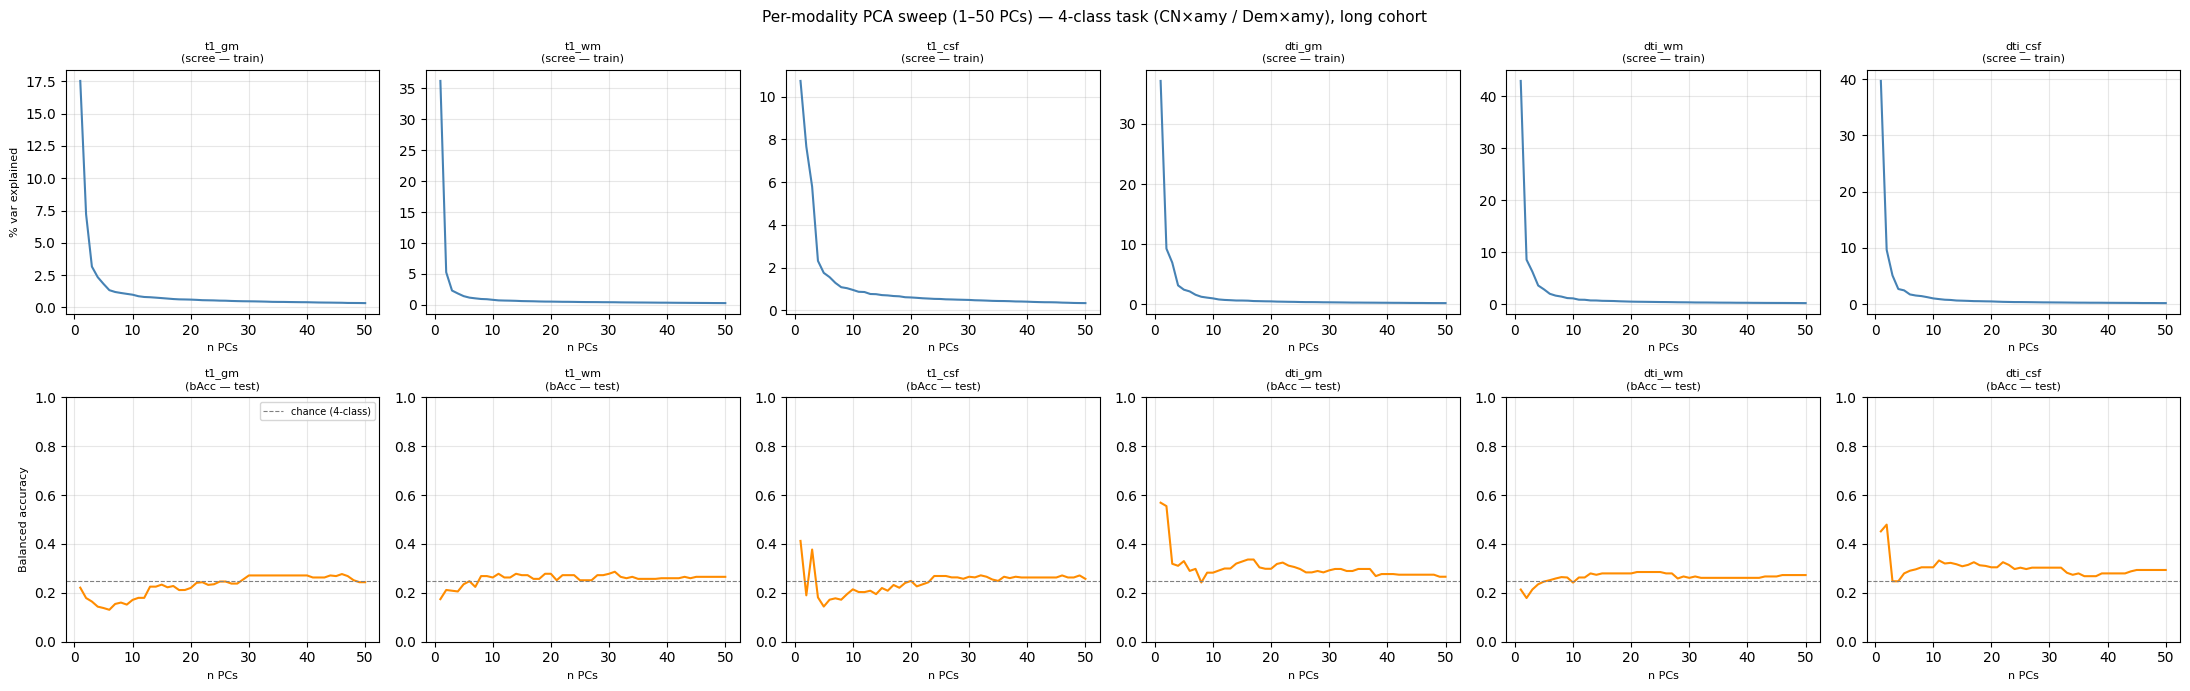

In [52]:
# --- 2×6 plot grid ---
fig, axes = plt.subplots(2, 6, figsize=(22, 7))

for col, mod in enumerate(MODALITIES):
    sub_s = scree_df[scree_df["modality"] == mod]
    sub_b = bacc_df[bacc_df["modality"]  == mod]

    ax_s = axes[0, col]
    ax_s.plot(sub_s["n_pc"], sub_s["var_explained"] * 100, color="steelblue", lw=1.5)
    ax_s.set_title(f"{mod}\n(scree — train)", fontsize=8)
    ax_s.set_xlabel("n PCs", fontsize=8)
    ax_s.set_ylabel("% var explained" if col == 0 else "", fontsize=8)
    ax_s.grid(True, alpha=0.3)

    ax_b = axes[1, col]
    ax_b.plot(sub_b["n_pc"], sub_b["bAcc"], color="darkorange", lw=1.5)
    ax_b.axhline(0.25, color="grey", lw=0.8, ls="--", label="chance (4-class)")
    ax_b.set_xlabel("n PCs", fontsize=8)
    ax_b.set_ylabel("Balanced accuracy" if col == 0 else "", fontsize=8)
    ax_b.set_title(f"{mod}\n(bAcc — test)", fontsize=8)
    ax_b.set_ylim(0, 1)
    ax_b.grid(True, alpha=0.3)
    if col == 0:
        ax_b.legend(fontsize=7)

fig.suptitle(
    "Per-modality PCA sweep (1–50 PCs) — 4-class task (CN×amy / Dem×amy), long cohort",
    fontsize=11
)
plt.tight_layout()
plt.show()

In [53]:
# --- CN vs AD / CN vs impaired: PCA counts + SVM helpers ----------------------------
# PC counts per modality; combined stack uses min(130, sum of PCs in that stack).
TEST_SIZE, SPLIT_SEED, SVM_SEED = 0.2, 0, 0
MOD_ORDER = ("t1_gm", "t1_wm", "t1_csf", "dti_gm", "dti_wm", "dti_csf")
T1_ORDER = ("t1_gm", "t1_wm", "t1_csf")
DTI_ORDER = ("dti_gm", "dti_wm", "dti_csf")
N_PC_BY_DATASET = {
    "t1_gm": 80,
    "t1_wm": 120,
    "t1_csf": 100,
    "dti_gm": 70,
    "dti_wm": 100,
    "dti_csf": 120,
    "combined": 130,
}

import gc

In [54]:
def cn_dem_combined_masked_minmax(meta_df, X_raw_dict, mask_cd, mod_order=None):
    # MinMax on CN per column, stacked modalities; rows only for outcome subset (memory-safe).
    mods = tuple(mod_order) if mod_order is not None else MOD_ORDER
    cn_mask = meta_df["group"].eq("CN").values
    cd_row_idx = np.flatnonzero(mask_cd)
    blocks = []
    for m in mods:
        Xm = np.asarray(X_raw_dict[m])
        mm = MinMaxScaler(feature_range=(0, 1)).fit(np.asarray(Xm[cn_mask]))
        blocks.append(mm.transform(np.asarray(Xm[cd_row_idx])).astype(np.float32))
        gc.collect()
    out = np.hstack(blocks)
    gc.collect()
    return out

def _effective_n_pc(n_requested, X_tr):
    return min(int(n_requested), X_tr.shape[0], max(1, X_tr.shape[1]))

def _combined_n_requested(mod_order):
    return min(N_PC_BY_DATASET["combined"], sum(N_PC_BY_DATASET[m] for m in mod_order))

def cn_svm_binary_metrics(meta_df,X_raw_dict,mod_order,comparison,*,cohort_label,block_label,verbose=True):
    # comparison: cn_dem | cn_mci_dem
    g = meta_df["group"].astype(str)

    if comparison == "cn_dem":
        mask = g.isin(["CN", "Dementia"]).values
        task_name = "CN_vs_Dementia"
        gm = g.loc[mask]
        pos = gm.eq("Dementia").astype(int).values
        y_desc = {"CN": int(gm.eq("CN").sum()), "Dementia": int(gm.eq("Dementia").sum())}
    elif comparison == "cn_mci_dem":
        mask = g.isin(["CN", "MCI", "Dementia"]).values
        task_name = "CN_vs_MCI_or_Dementia"
        gm = g.loc[mask]
        pos = (~gm.eq("CN")).astype(int).values
        y_desc = {
            "CN": int(gm.eq("CN").sum()),
            "MCI": int(gm.eq("MCI").sum()),
            "Dementia": int(gm.eq("Dementia").sum()),
        }
    else:
        raise ValueError(comparison)

    yy = np.asarray(pos, dtype=np.int64)

    if yy.sum() == 0 or yy.sum() == len(yy):
        if verbose:
            print(
                f"[{cohort_label}|{block_label}|{comparison}] skip single class "
                f"(n={len(yy)} counts={y_desc})"
            )
        return pd.DataFrame()

    idx = np.arange(len(yy))
    try:
        idx_train, idx_test = train_test_split(
            idx,
            test_size=TEST_SIZE,
            stratify=yy,
            random_state=SPLIT_SEED,
        )
    except ValueError as exc:
        if verbose:
            print(
                f"[{cohort_label}|{block_label}|{comparison}] stratify failed ({exc}); skip"
            )
        return pd.DataFrame()

    y_tr, y_te = yy[idx_train], yy[idx_test]

    rows = []
    tag = f"[{cohort_label}|{block_label}|{task_name}]"

    for name in list(mod_order) + ["combined"]:
        if name != "combined":
            X = X_raw_dict[name][mask].astype(np.float32)
            scaler = StandardScaler().fit(X[idx_train])
            Xs = scaler.transform(X).astype(np.float32)
            X_tr, X_te = Xs[idx_train], Xs[idx_test]
            n_req = N_PC_BY_DATASET[name]
        else:
            Xv = cn_dem_combined_masked_minmax(meta_df, X_raw_dict, mask, mod_order=mod_order)
            X_tr, X_te = Xv[idx_train], Xv[idx_test]
            n_req = _combined_n_requested(mod_order)

        n_pc = _effective_n_pc(n_req, X_tr)
        if verbose and (n_pc != n_req):
            print(
                f"{tag} {name}: n_pc {n_req} -> {n_pc} "
                f"(cap train={X_tr.shape[0]} feat={X_tr.shape[1]})"
            )

        pca = PCA(
            n_components=n_pc,
            random_state=SPLIT_SEED,
            svd_solver="randomized" if X_tr.shape[1] > 10_000 else "auto",
        ).fit(X_tr)
        Z_tr = pca.transform(X_tr)
        Z_te = pca.transform(X_te)

        clf = SVC(class_weight="balanced", random_state=SVM_SEED).fit(Z_tr, y_tr)
        y_pred = clf.predict(Z_te)
        bacc = balanced_accuracy_score(y_te, y_pred)
        tn, fp, fn, tp = confusion_matrix(y_te, y_pred, labels=[0, 1]).ravel()
        sens = tp / (tp + fn) if (tp + fn) else float("nan")
        spec = tn / (tn + fp) if (tn + fp) else float("nan")

        rows.append(
            {
                "cohort_source": cohort_label,
                "modality_block": block_label,
                "task": task_name,
                "dataset": name,
                "n_pc": int(n_pc),
                "bAcc": float(bacc),
                "Sens_positive": float(sens),
                "Spec_CN": float(spec),
                "n_test": int(len(y_te)),
                "n_subset": int(len(yy)),
            }
        )
        if verbose:
            print(
                f"{tag} {name:>9s} n_pc={n_pc:3d} "
                f"bAcc={bacc:.4f} Sens+={sens:.4f} Spec_CN={spec:.4f}"
            )

    if verbose:
        cmp_lbl = "AD_Dementia_only" if comparison == "cn_dem" else "MCI_or_Dementia"
        tail = (
            f"{tag} n_subset={len(yy)} "
            + " ".join(f"{k}={v}" for k, v in y_desc.items())
            + f" train={len(idx_train)} test={len(idx_test)} positive={cmp_lbl}"
        )
        print(tail)

    return pd.DataFrame(rows)

In [55]:
# Split metrics: long/short × T1 vs DTI × (CN vs Dementia | CN vs MCI+Dementia).

# Sens_positive = recall AD (cn_dem); recall impaired (cn_mci_dem).

parts = []
for cohort_label, mdf, xdict in (
    ("long", meta_long, X_raw_long),
    ("short", meta_short, X_raw_short),
):
    for block_label, mod_order in (
        ("t1", T1_ORDER),
        ("dti", DTI_ORDER),
    ):
        for comparison in ("cn_dem", "cn_mci_dem"):
            sub = cn_svm_binary_metrics(
                mdf,
                xdict,
                mod_order,
                comparison,
                cohort_label=cohort_label,
                block_label=block_label,
                verbose=True,
            )
            parts.append(sub)

cn_dem_metrics_split = pd.concat([p for p in parts if not p.empty], ignore_index=True)

print("\n=== Pooled: six modalities, CN vs Dementia baseline ===")
cn_vs_dem_results = cn_svm_binary_metrics(
    meta,
    X_raw,
    MOD_ORDER,
    "cn_dem",
    cohort_label="pooled",
    block_label="all6",
    verbose=True,
)
cn_dem_metrics_split


[long|t1|CN_vs_Dementia]     t1_gm n_pc= 80 bAcc=0.8261 Sens+=0.6875 Spec_CN=0.9647
[long|t1|CN_vs_Dementia]     t1_wm n_pc=120 bAcc=0.7165 Sens+=0.5625 Spec_CN=0.8706
[long|t1|CN_vs_Dementia]    t1_csf n_pc=100 bAcc=0.6776 Sens+=0.4375 Spec_CN=0.9176
[long|t1|CN_vs_Dementia]  combined n_pc=130 bAcc=0.8261 Sens+=0.6875 Spec_CN=0.9647
[long|t1|CN_vs_Dementia] n_subset=501 CN=421 Dementia=80 train=400 test=101 positive=AD_Dementia_only
[long|t1|CN_vs_MCI_or_Dementia]     t1_gm n_pc= 80 bAcc=0.7523 Sens+=0.6575 Spec_CN=0.8471
[long|t1|CN_vs_MCI_or_Dementia]     t1_wm n_pc=120 bAcc=0.7376 Sens+=0.6986 Spec_CN=0.7765
[long|t1|CN_vs_MCI_or_Dementia]    t1_csf n_pc=100 bAcc=0.7268 Sens+=0.6301 Spec_CN=0.8235
[long|t1|CN_vs_MCI_or_Dementia]  combined n_pc=130 bAcc=0.7337 Sens+=0.6438 Spec_CN=0.8235
[long|t1|CN_vs_MCI_or_Dementia] n_subset=787 CN=421 MCI=286 Dementia=80 train=629 test=158 positive=MCI_or_Dementia
[long|dti|CN_vs_Dementia]    dti_gm n_pc= 70 bAcc=0.6717 Sens+=0.4375 Spec_CN=0.90

,cohort_source,modality_block,task,dataset,n_pc,bAcc,Sens_positive,Spec_CN,n_test,n_subset
0,long,t1,CN_vs_Dementia,t1_gm,80,0.826103,0.687500,0.964706,101,501
1,long,t1,CN_vs_Dementia,t1_wm,120,0.716544,0.562500,0.870588,101,501
2,long,t1,CN_vs_Dementia,t1_csf,100,0.677574,0.437500,0.917647,101,501
3,long,t1,CN_vs_Dementia,combined,130,0.826103,0.687500,0.964706,101,501
4,long,t1,CN_vs_MCI_or_Dementia,t1_gm,80,0.752297,0.657534,0.847059,158,787
5,long,t1,CN_vs_MCI_or_Dementia,t1_wm,120,0.737550,0.698630,0.776471,158,787
6,long,t1,CN_vs_MCI_or_Dementia,t1_csf,100,0.726833,0.630137,0.823529,158,787
7,long,t1,CN_vs_MCI_or_Dementia,combined,130,0.733683,0.643836,0.823529,158,787
8,long,dti,CN_vs_Dementia,dti_gm,70,0.671691,0.437500,0.905882,101,501
9,long,dti,CN_vs_Dementia,dti_wm,100,0.710662,0.562500,0.858824,101,501
